In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root

### $\dot{\rho_X}=-3H(1+w)(\rho_X -\rho_\Lambda)+Q$ 
w is the affine parameter and Q the interaction term. $Q=qH(\rho_X-\rho_\Lambda)$ q is interaction strength

### $\dot{\rho_m}=-3H\rho_m-Q$

This is an affine interacting model of DE that has density $\rho_X=\rho_{dynamic}+\rho_\Lambda =(1-\alpha)\rho_X +\alpha \rho_X $ where the equation of state (EoS) above only evolves $\rho_{dyn}$. We find that the EoS of dark energy parameter $w_X=w-(1+w)\frac{\rho_\Lambda}{\rho_X}$. But we want to study the interacting EoS $w_{int}$ instead.
From 
$\dot{\rho_X}=-3H(1+w)(\rho_X -\rho_\Lambda)+Q = -3H(1+w_{int})\rho_X$
we find that:

### $w_{int} = -1 +(1+w)\frac{(\rho_X-\rho_\Lambda)}{\rho_\Lambda} -\frac{q(\rho_X -\rho_m)}{3\rho_X} = -1 +(1+w)\frac{x}{x+z} -\frac{q(x+z-y)}{3(x+z)} $

using dimensionless variables $x=\Omega_{dyn}=\rho_{dyn}/3H^2$, $y=\Omega_{m}=\rho_{m}/3H^2$ and $z=\Omega_{\Lambda}=\rho_{\Lambda}/3H^2$ and in N=ln(a) time not t time where dt=NdN
##### $    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R ~~(DE) $
##### $    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R  ~~(DM) $
##### $   dz= 3*z*x*(1+w) +3*y*z+ 4*z*R ~~(constant~~~DE)$
##### $   dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2 ~~ (radiation)$

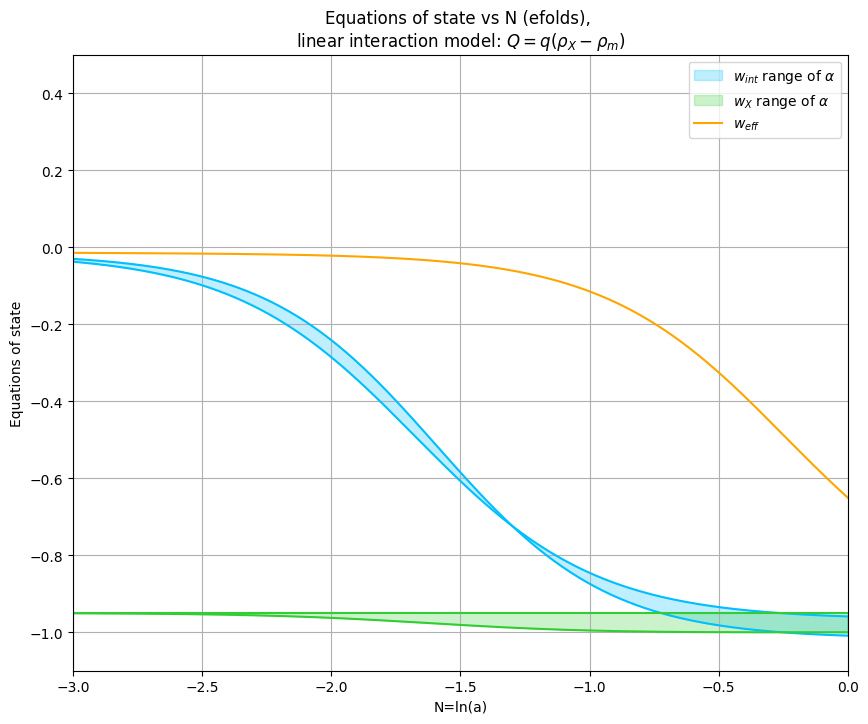

In [2]:
w,q=-0.95,0.05
alpha = np.linspace(0,1,50) # the fraction of the total DE that is affine or constant.
a=1
simulationTime=np.linspace(0,-8,500)
ICs=[0.685,0.315,9e-5]# [OmegaDE,OmegaM,OmegaR] where OmegaDE is total dyn and lambda x+z.
# using PLANCK 2018  ICs from the paper and refernece in text.
Omega_DE=0.685
Omega_m=0.315
Omega_R=9e-5
x0 = (1 - a) * Omega_DE
y0 = Omega_m
z0 = a * Omega_DE
R0 = Omega_R

def system_linear(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]



def vary_alpha(a,model,Q):
    x0 = (1 - a) * Omega_DE
    y0 = Omega_m
    z0 = a * Omega_DE
    R0 = Omega_R
    sol = solve_ivp(model, [0,-8], [x0,y0,z0,R0] ,method='RK45',t_eval=simulationTime,rtol=1e-12,atol=1e-12)
    x, y, z, R = sol.y
    Q = Q(x, y, z, R)
    denom_DE = x + z + 1e-6

    wX = w-(1+w)*z*(x + y + z + R)/((x+z)*(x + y + z + R))
    weff = (w*x - z + (1/3)*R) / (x + z + y + R + 1e-12)
    wint = -1 + (1+w)*x*(x + y + z + R)/((x+z)*(x + y + z + R)) -Q/(3*(x+z)*(x + y + z + R))
    return wint, wX, weff

def Q_linear(x, y, z, R):
    return q*(x + z - y)


sol0 = solve_ivp(system_linear, [0,-20], [x0,y0,z0,R0] ,method='RK45',t_eval=simulationTime,rtol=1e-12,atol=1e-12)
x_lin,y_lin,z_lin,R_lin = sol0.y



#linear
plt.figure(figsize=(10,8))
wX_0=(w*x_lin -z_lin)/(x_lin+z_lin+1e-9)
weff_0=(w*x_lin -z_lin +1/3 *R_lin)/(x_lin+z_lin+y_lin+R_lin+1e-9)
denom_DE0 = np.maximum(1e-12, x_lin + z_lin)
Q0 = q *(x_lin+z_lin-y_lin) 
wint_non0 = -1 + (1+w)*x_lin/(denom_DE0) -Q0/(3*denom_DE0)

wint0, wX0, weff0 = vary_alpha(a=0, model=system_linear,Q=Q_linear)
wint1, wX1, weff1 = vary_alpha(a=1,model=system_linear ,Q=Q_linear)
plt.fill_between(simulationTime, np.minimum(wint0, wint1), np.maximum(wint0, wint1),alpha=0.25, label=r'$w_{int}$ range of $\alpha$',color='deepskyblue')
plt.plot(simulationTime,wint0,c='deepskyblue')
plt.plot(simulationTime,wint1,c='deepskyblue')
plt.fill_between(simulationTime, np.minimum(wX0, wX1), np.maximum(wX0, wX1),alpha=0.25, label=r'$w_{X}$ range of $\alpha$',color='limegreen')
plt.plot(simulationTime,wX0,c='limegreen')
plt.plot(simulationTime,wX1,c='limegreen')

plt.plot(simulationTime,weff0,label=r'$w_{eff}$',color='orange')
plt.legend()
plt.title(f'Equations of state vs N (efolds), \n' r'linear interaction model: $Q={q (\rho_X-\rho_m) }$')
plt.xlabel('N=ln(a)')
plt.ylabel('Equations of state')
plt.ylim(-1.1,0.5)
plt.xlim(-3,0)
plt.grid()



Hi Ian. The problem I am having with the code above is that it is unphysical. When solving the linear ODEs for $\rho_X$ and $\rho_m$ and calculating $w_{int}$ I find that it should tend to infinity at early time, before coming down as matter grows, however instead my plot shows it at 0 for early time and before (I have checked all the way back to N=-20 and it is still 0). This is physically wrong and so I am not sure how I can get the correct dynamics from the correct model?